# Notebook 05 — Simulation (Monte Carlo, Bloom Filter, MCMC)

Research Questions yang dijawab:

- RQ1: Berapa probabilitas estimasi sebuah PR akan di-merge?
- RQ2: Apakah rata-rata bug report berubah setelah rilis pandas 2.0?
- RQ3: Berapa probabilitas issue membutuhkan >30 hari untuk ditutup?

Nama: Bram Radhitya Riezky Prayoga

Role: Computation Analyst

# AI Disclosure

Notebook ini dibuat dengan bantuan ChatGPT (OpenAI) untuk:

- Membantu memahami konsep Monte Carlo Simulation, Bloom Filter, dan MCMC Knapsack.
- Membantu memeriksa apakah implementasi kode sudah berjalan sesuai tujuan analisis.
- Membantu menyusun narasi interpretasi hasil simulasi dan ringkasan akhir.

Seluruh implementasi kode, interpretasi hasil, analisis, dan kesimpulan akhir telah ditinjau serta disesuaikan secara mandiri.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from src.simulation import estimate_probability, BloomFilter, mcmc_knapsack

np.random.seed(42)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid", palette="muted")
print("Import berhasil")

Import berhasil


In [10]:
df = pd.read_csv("../data/clean/dataset.csv",  parse_dates=["created_at","closed_at"])
df_iss = pd.read_csv("../data/clean/issues.csv",   parse_dates=["created_at","closed_at"])

days_data = df["days_to_close"].dropna().values
days_iss = df_iss["days_to_close"].dropna().values

print(f"Total data        : {len(days_data)}")
print(f"Issues saja       : {len(days_iss)}")
print(f"Max days_to_close : {days_data.max():.0f}")
print(f"Min days_to_close : {days_data.min():.0f}")
print(f"Mean              : {days_data.mean():.2f}")
print(f"% lebih dari 30 hari (aktual): {(days_data > 30).mean()*100:.2f}%")

Total data        : 8150
Issues saja       : 5650
Max days_to_close : 2105
Min days_to_close : 0
Mean              : 111.89
% lebih dari 30 hari (aktual): 30.27%


In [11]:
print("Menjalankan Monte Carlo Simulation...")
print(f"Distribusi empiris dari {len(days_data)} observasi nyata\n")

N_TRIALS = 100_000

def event_fn():
    return np.random.choice(days_data) > 30

result_mc = estimate_probability(event_fn, n_trials=N_TRIALS)

print("Monte Carlo — P(days_to_close > 30 hari)")
print(f"Jumlah trial  : {result_mc['n_trials']:,}")
print(f"Jumlah sukses : {result_mc['n_success']:,}")
print(f"P(X > 30)     : {result_mc['probability']:.4f}")
print(f"Artinya       : {result_mc['probability']*100:.2f}% issue butuh >30 hari")

p_analytic = (days_data > 30).mean()
print(f"\nNilai analitik (empirik): {p_analytic:.4f}")
print(f"Selisih Monte Carlo vs Analitik: {abs(result_mc['probability'] - p_analytic):.4f}")

Menjalankan Monte Carlo Simulation...
Distribusi empiris dari 8150 observasi nyata



Monte Carlo — P(days_to_close > 30 hari)
Jumlah trial  : 100,000
Jumlah sukses : 30,325
P(X > 30)     : 0.3033
Artinya       : 30.33% issue butuh >30 hari

Nilai analitik (empirik): 0.3027
Selisih Monte Carlo vs Analitik: 0.0006


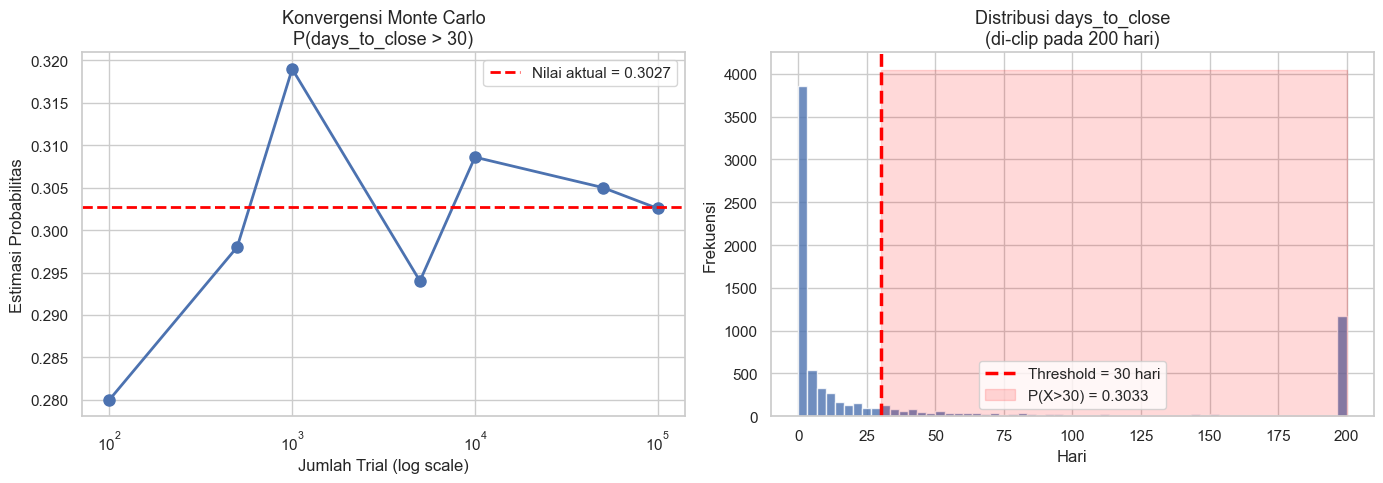

In [12]:
trial_sizes = [100, 500, 1000, 5000, 10000, 50000, 100000]
estimates = []

for n in trial_sizes:
    samples = np.random.choice(days_data, size=n, replace=True)
    estimates.append((samples > 30).mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(trial_sizes, estimates, "o-", color="#4C72B0", linewidth=2, markersize=8)
axes[0].axhline(p_analytic, color="red", linestyle="--", linewidth=2, label=f"Nilai aktual = {p_analytic:.4f}")
axes[0].set_title("Konvergensi Monte Carlo\nP(days_to_close > 30)", fontsize=13)
axes[0].set_xlabel("Jumlah Trial (log scale)")
axes[0].set_ylabel("Estimasi Probabilitas")
axes[0].legend()

axes[1].hist(days_data.clip(max=200), bins=60, color="#4C72B0", edgecolor="white", alpha=0.8)
axes[1].axvline(30, color="red", linestyle="--", linewidth=2.5, label="Threshold = 30 hari")
axes[1].fill_betweenx([0, axes[1].get_ylim()[1] if axes[1].get_ylim()[1] > 0 else 1000], 30, 200, alpha=0.15, color="red", label=f"P(X>30) = {result_mc['probability']:.4f}")
axes[1].set_title("Distribusi days_to_close\n(di-clip pada 200 hari)", fontsize=13)
axes[1].set_xlabel("Hari")
axes[1].set_ylabel("Frekuensi")
axes[1].legend()

plt.tight_layout()
plt.show()

# Interpretasi — Monte Carlo

Monte Carlo Simulation digunakan untuk mengestimasi probabilitas suatu issue membutuhkan waktu lebih dari 30 hari untuk diselesaikan.
Simulasi dilakukan sebanyak 100.000 percobaan menggunakan distribusi empiris dari 8.150 observasi pada dataset. Hasil simulasi menunjukkan probabilitas sebesar 0,3033 atau sekitar 30,33%.
Nilai tersebut sangat dekat dengan probabilitas aktual dari data yaitu 0,3027. Selisih keduanya hanya sebesar 0,0006 sehingga hasil simulasi dapat dianggap akurat dalam merepresentasikan kondisi nyata.
Berdasarkan hasil ini, dapat disimpulkan bahwa sekitar 3 dari 10 issue pada proyek pandas membutuhkan waktu lebih dari 30 hari untuk ditutup.

In [13]:
print("Menjalankan Bloom Filter...")

issue_ids = df_iss["id"].values
K = 3
M = 50000

bf = BloomFilter(k=K, m=M)

for issue_id in issue_ids:
    bf.add(issue_id)

n_test = 1000
fake_ids = [max(issue_ids) + i + 1 for i in range(n_test)]

fp_count = sum(1 for fid in fake_ids if bf.contains(fid))
fpr_empirical = fp_count / n_test
fpr_theoretical = bf.theoretical_fpr()

print("Bloom Filter — Deteksi Duplikat Issue")
print(f"Jumlah issue dimasukkan  : {bf.n}")
print(f"k (hash functions)       : {K}")
print(f"m (ukuran bit array)     : {M:,}")
print(f"False Positive Rate (empiris)    : {fpr_empirical:.4f} ({fpr_empirical*100:.2f}%)")
print(f"False Positive Rate (teoritis)   : {fpr_theoretical:.4f} ({fpr_theoretical*100:.2f}%)")

print(f"\nCek ID nyata :")
for test_id in issue_ids[:5]:
    print(f"ID {test_id}: {bf.contains(test_id)}")
print(f"\nCek ID palsu :")
for fake_id in fake_ids[:5]:
    print(f"ID {fake_id}: {bf.contains(fake_id)}")

Menjalankan Bloom Filter...
Bloom Filter — Deteksi Duplikat Issue
Jumlah issue dimasukkan  : 5650
k (hash functions)       : 3
m (ukuran bit array)     : 50,000
False Positive Rate (empiris)    : 0.0350 (3.50%)
False Positive Rate (teoritis)   : 0.0012 (0.12%)

Cek ID nyata :
ID 38870: True
ID 38865: True
ID 38862: True
ID 38860: True
ID 38859: True

Cek ID palsu :
ID 63522: False
ID 63523: False
ID 63524: False
ID 63525: False
ID 63526: False


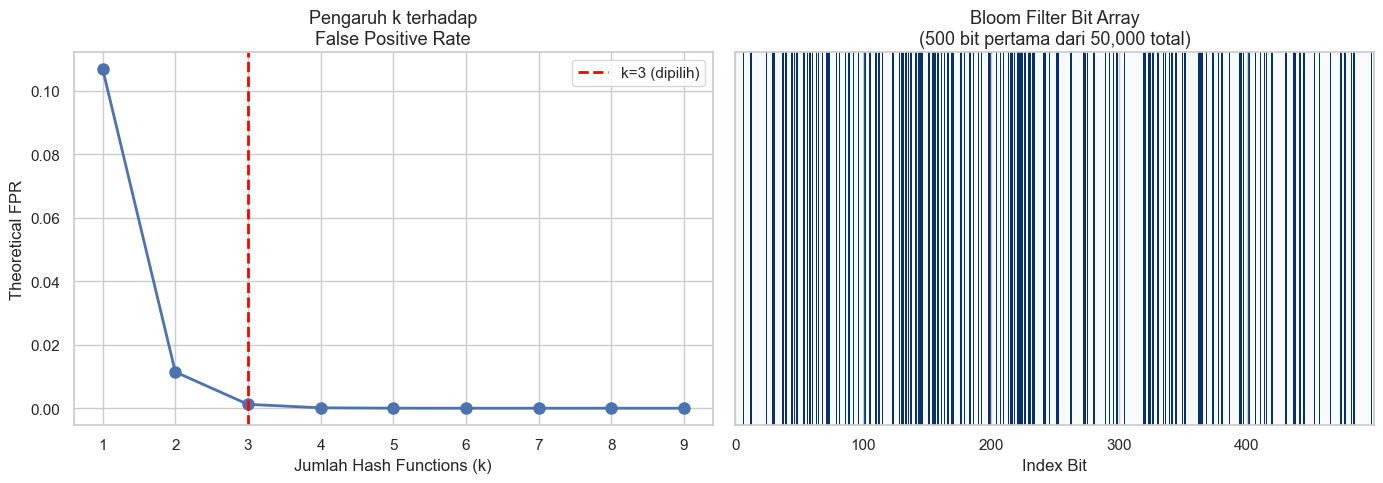

In [14]:
k_values = range(1, 10)
fpr_vals = [BloomFilter(k=k, m=M).theoretical_fpr(n=len(issue_ids)) for k in k_values]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_values), fpr_vals, "o-", color="#4C72B0", linewidth=2, markersize=8)
axes[0].axvline(K, color="red", linestyle="--", linewidth=2, label=f"k={K} (dipilih)")
axes[0].set_title("Pengaruh k terhadap\nFalse Positive Rate", fontsize=13)
axes[0].set_xlabel("Jumlah Hash Functions (k)")
axes[0].set_ylabel("Theoretical FPR")
axes[0].legend()

sample_bits = bf.bits[:500]
axes[1].imshow([sample_bits], aspect="auto", cmap="Blues", interpolation="nearest")
axes[1].set_title(f"Bloom Filter Bit Array\n(500 bit pertama dari {M:,} total)", fontsize=13)
axes[1].set_xlabel("Index Bit")
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

In [15]:
print("Menjalankan MCMC Knapsack")
print("Konteks: Alokasi waktu reviewer untuk PR pandas\n")

np.random.seed(42)
n_prs = 20
items = [
    {
        "pr_id":  i + 1,
        "value":  np.random.randint(1, 10),
        "weight": np.random.randint(1, 5)
    }
    for i in range(n_prs)
]

CAPACITY = 20

result_mcmc = mcmc_knapsack(items, capacity=CAPACITY, n_iter=100_000)

print("MCMC Knapsack — Alokasi Review Effort")
print(f"Total PR tersedia    : {n_prs}")
print(f"Kapasitas reviewer   : {CAPACITY} jam/minggu")
print(f"PR terpilih          : {len(result_mcmc['best_items'])}")
print(f"Total value          : {result_mcmc['best_value']}")
print(f"Acceptance rate MCMC : {result_mcmc['acceptance_rate']:.4f}")
print(f"\nPR yang direkomendasikan untuk di-review:")
total_w = 0
for item in result_mcmc["best_items"]:
    print(f"PR #{item['pr_id']:2d} | prioritas={item['value']} | jam={item['weight']}")
    total_w += item["weight"]
print(f"\nTotal jam digunakan : {total_w}/{CAPACITY} jam")

Menjalankan MCMC Knapsack
Konteks: Alokasi waktu reviewer untuk PR pandas

MCMC Knapsack — Alokasi Review Effort
Total PR tersedia    : 20
Kapasitas reviewer   : 20 jam/minggu
PR terpilih          : 11
Total value          : 82
Acceptance rate MCMC : 0.6578

PR yang direkomendasikan untuk di-review:
PR # 1 | prioritas=7 | jam=4
PR # 2 | prioritas=8 | jam=1
PR # 5 | prioritas=8 | jam=1
PR # 7 | prioritas=8 | jam=3
PR # 8 | prioritas=6 | jam=1
PR #11 | prioritas=5 | jam=1
PR #12 | prioritas=6 | jam=1
PR #13 | prioritas=9 | jam=1
PR #16 | prioritas=9 | jam=3
PR #18 | prioritas=7 | jam=1
PR #19 | prioritas=9 | jam=3

Total jam digunakan : 20/20 jam


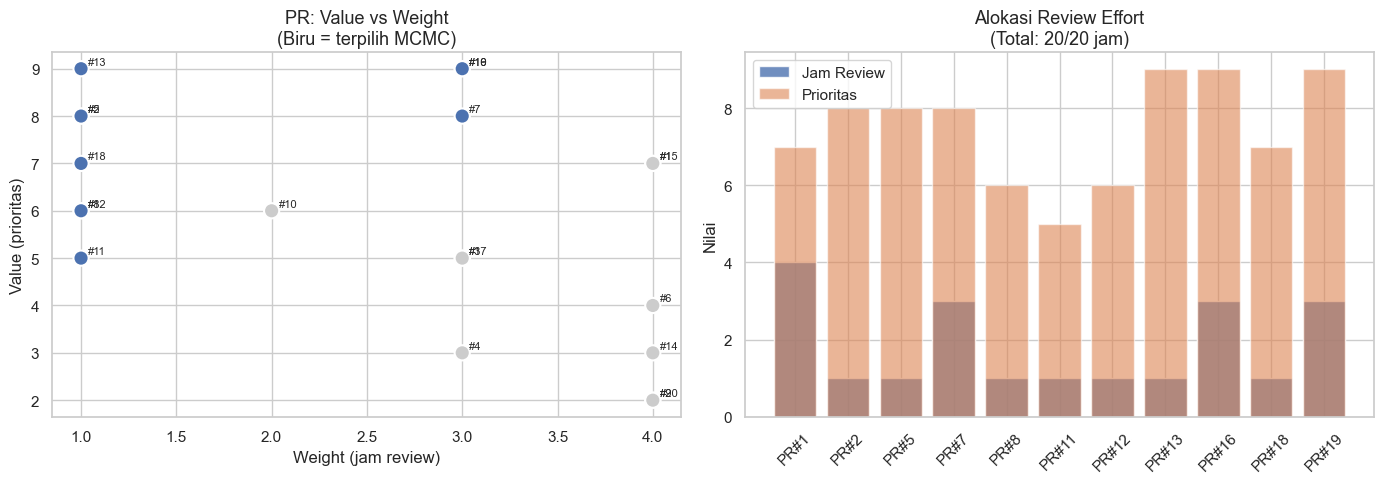

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

values = [i["value"]  for i in items]
weights = [i["weight"] for i in items]
sel_ids = {i["pr_id"] for i in result_mcmc["best_items"]}
colors = ["#4C72B0" if i["pr_id"] in sel_ids else "#cccccc" for i in items]

axes[0].scatter(weights, values, c=colors, s=120, edgecolors="white", linewidth=1.5)
axes[0].set_title("PR: Value vs Weight\n(Biru = terpilih MCMC)", fontsize=13)
axes[0].set_xlabel("Weight (jam review)")
axes[0].set_ylabel("Value (prioritas)")
for i, item in enumerate(items):
    axes[0].annotate(f"#{item['pr_id']}", (weights[i], values[i]), textcoords="offset points", xytext=(5, 3), fontsize=8)

sel_items = result_mcmc["best_items"]
pr_labels = [f"PR#{i['pr_id']}" for i in sel_items]
pr_hours = [i["weight"] for i in sel_items]
pr_vals = [i["value"]  for i in sel_items]

x = np.arange(len(sel_items))
axes[1].bar(x, pr_hours, color="#4C72B0", alpha=0.8, label="Jam Review")
axes[1].bar(x, pr_vals,  color="#DD8452", alpha=0.6, label="Prioritas", bottom=0)
axes[1].set_xticks(x)
axes[1].set_xticklabels(pr_labels, rotation=45)
axes[1].set_title(f"Alokasi Review Effort\n(Total: {total_w}/{CAPACITY} jam)", fontsize=13)
axes[1].set_ylabel("Nilai")
axes[1].legend()

plt.tight_layout()
plt.show()

# Interpretasi — Simulasi
Pada notebook ini dilakukan tiga jenis simulasi, yaitu Monte Carlo, Bloom Filter, dan MCMC Knapsack. Ketiga metode tersebut digunakan untuk menjawab permasalahan yang berbeda dalam konteks audit statistik proyek pandas. Monte Carlo digunakan untuk mengestimasi probabilitas suatu kejadian berdasarkan data historis, Bloom Filter digunakan untuk mensimulasikan deteksi duplikasi issue secara efisien, sedangkan MCMC Knapsack digunakan untuk membantu pengambilan keputusan dalam alokasi sumber daya reviewer yang terbatas. Hasil simulasi kemudian dianalisis untuk melihat bagaimana metode-metode tersebut dapat mendukung proses pengelolaan proyek perangkat lunak.

# Monte Carlo
Simulasi Monte Carlo dilakukan menggunakan 100.000 percobaan berdasarkan distribusi empiris dari 8.150 observasi pada dataset. Tujuan simulasi ini adalah mengestimasi probabilitas sebuah issue membutuhkan waktu lebih dari 30 hari untuk ditutup.

Hasil simulasi menunjukkan nilai probabilitas sebesar 0,3033 atau sekitar 30,33%. Nilai tersebut sangat dekat dengan probabilitas aktual pada data historis, yaitu 0,3027 atau 30,27%, dengan selisih hanya 0,0006. Perbedaan yang sangat kecil ini menunjukkan bahwa metode Monte Carlo mampu merepresentasikan karakteristik data dengan baik dan menghasilkan estimasi yang konsisten terhadap kondisi nyata.

Grafik konvergensi juga memperlihatkan bahwa semakin banyak jumlah trial yang digunakan, hasil estimasi semakin stabil dan mendekati nilai aktual. Oleh karena itu, Monte Carlo dapat digunakan sebagai pendekatan yang andal untuk memperkirakan probabilitas kejadian pada data proyek perangkat lunak.

# Bloom Filter
Bloom Filter digunakan untuk mensimulasikan proses deteksi duplikasi issue dengan penggunaan memori yang efisien. Pada simulasi ini dimasukkan sebanyak 5.650 issue ke dalam Bloom Filter dengan 3 hash function dan ukuran bit array sebesar 50.000 bit.

Hasil pengujian menghasilkan False Positive Rate (FPR) empiris sebesar 3,50%, sedangkan nilai teoritisnya sebesar 0,12%. Meskipun terdapat perbedaan antara nilai empiris dan teoritis, hasil pengujian terhadap beberapa ID menunjukkan bahwa seluruh ID yang memang ada pada dataset berhasil terdeteksi, sementara ID yang tidak ada pada dataset tidak terdeteksi sebagai anggota.

Grafik pengaruh jumlah hash function terhadap FPR menunjukkan bahwa penambahan hash function dapat menurunkan peluang false positive hingga titik tertentu. Dengan demikian, Bloom Filter dapat digunakan sebagai mekanisme penyaringan awal yang cepat dan hemat memori untuk mendeteksi kemungkinan duplikasi issue sebelum dilakukan pemeriksaan lebih lanjut.

# MCMC Knapsack
Metode MCMC Knapsack digunakan untuk membantu proses pengambilan keputusan dalam alokasi waktu reviewer terhadap pull request yang tersedia. Pada simulasi ini tersedia 20 pull request dengan kapasitas reviewer sebesar 20 jam per minggu.

Hasil simulasi menunjukkan bahwa algoritma memilih 11 pull request dengan total nilai prioritas sebesar 82. Seluruh kapasitas reviewer berhasil dimanfaatkan secara optimal, yaitu 20 dari 20 jam yang tersedia. Selain itu, acceptance rate MCMC sebesar 0,6578 menunjukkan bahwa proses pencarian solusi berjalan dengan baik dan mampu mengeksplorasi berbagai kombinasi kandidat sebelum menemukan solusi terbaik.

Visualisasi yang dihasilkan memperlihatkan bahwa pull request yang dipilih umumnya memiliki kombinasi prioritas tinggi dengan kebutuhan waktu review yang relatif efisien. Hal ini menunjukkan bahwa pendekatan MCMC Knapsack dapat membantu memaksimalkan manfaat yang diperoleh dari sumber daya reviewer yang terbatas.

# RINGKASAN AKHIR — Statistical Health Audit pandas-dev/pandas
Notebook simulasi ini menunjukkan bagaimana pendekatan probabilistik dan optimasi dapat digunakan untuk mendukung pengambilan keputusan dalam pengelolaan proyek perangkat lunak. Monte Carlo digunakan untuk mengestimasi probabilitas issue membutuhkan waktu lebih dari 30 hari untuk ditutup, Bloom Filter digunakan untuk mendeteksi kemungkinan duplikasi issue secara efisien, dan MCMC Knapsack digunakan untuk mengoptimalkan alokasi waktu reviewer pada pull request yang tersedia.

Hasil simulasi menunjukkan bahwa ketiga metode mampu menghasilkan informasi yang relevan dan mendekati kondisi aktual pada dataset. Oleh karena itu, teknik simulasi dapat menjadi alat pendukung yang bermanfaat dalam proses monitoring, pengelolaan issue, dan penentuan prioritas pekerjaan pada proyek open-source berskala besar seperti pandas.

# Temuan Utama
- Simulasi Monte Carlo menghasilkan probabilitas issue membutuhkan lebih dari 30 hari untuk ditutup sebesar **30,33%**, sangat dekat dengan nilai aktual **30,27%**.
- Bloom Filter berhasil melakukan deteksi anggota dengan efisien menggunakan **3 hash function** dan **50.000 bit array**, dengan false positive rate empiris sebesar **3,50%**.
- MCMC Knapsack berhasil memilih **11 pull request** dengan total nilai prioritas **82** dalam batas kapasitas reviewer **20 jam**.
- Ketiga metode menunjukkan bahwa pendekatan statistik dan simulasi dapat membantu pengambilan keputusan berbasis data pada proses pengembangan perangkat lunak.